# Сердечно-сосудистый риск: нейросеть на табличных данных

**Что делаем:** по анализам и осмотру пациента определяем, высокий у него риск ССЗ или нет (столбец `prediction`).

**План:**
1. загрузить данные;
2. разделить на train / val / test;
3. почистить train: выбросы (z-score), пропуски (среднее), масштаб (StandardScaler);
4. обучить нейросеть: 1 скрытый слой, 32 нейрона, ReLU, 150 эпох;
5. проверить качество и сохранить прогноз в `outputs/task1_predictions.csv`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

RANDOM_STATE = 7

## Шаг 1. Данные

In [2]:
# Путь к данным: локально из репозитория или с GitHub (для Colab)
BASE = '../dataset/task1' if os.path.exists('../dataset/task1') else (
    'https://github.com/AI-is-out-there/check-your-biomed-datascience-skills-review/raw/refs/heads/dev/dataset/task1')

df = pd.read_csv(f'{BASE}/train.csv')
df_new = pd.read_csv(f'{BASE}/test_features.csv')  # пациенты, для которых нужен прогноз

print('Обучающая таблица:', df.shape)
print('Таблица для прогноза:', df_new.shape)
df.head(3)

Обучающая таблица: (800, 19)
Таблица для прогноза: (200, 18)


,patient_id,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,prediction,Статус_глюкозы,Доклинический_риск
0,1,41,1,24.24,81.04,113.19,62.54,50.65,4.595,4.65,NaN,NaN,1.379,115.52,0,165.8,0,0,0
1,4,53,0,19.84,73.44,119.75,71.59,48.15,4.431,5.08,2.268,2.022,1.467,93.39,0,248.1,0,0,0
2,5,53,1,24.28,82.06,127.07,70.34,56.73,4.997,5.04,2.459,1.325,0.967,88.41,0,230.5,0,0,0


> **Итог шага:** 800 пациентов для обучения и 200 для прогноза. В таблице для прогноза на один столбец меньше: нет `prediction`, его и предсказываем.

In [3]:
# prediction - то, что предсказываем.
# Статус_глюкозы и Доклинический_риск - это тоже ответы (из других задач), брать их как признаки нельзя.
label_cols = ['prediction', 'Статус_глюкозы', 'Доклинический_риск']
cols = [c for c in df.columns if c != 'patient_id' and c not in label_cols]

print('Признаков:', len(cols))
print(df['prediction'].value_counts().rename({0: 'низкий риск', 1: 'высокий риск'}))

Признаков: 15
prediction
низкий риск     655
высокий риск    145
Name: count, dtype: int64


> **Итог шага:** 15 признаков. Высокий риск у 145 пациентов из 800 (18%): здоровых примерно в 4.5 раза больше. Модели будет проще выучить здоровых, чем больных.

## Шаг 2. Разделение

Делим до любой обработки, чтобы val и test оставались «новыми» данными, которых модель не видела.
70% — обучение, 15% — val (следим за обучением), 15% — test (финальная оценка).

In [4]:
X_all, y_all = df[cols], df['prediction']

X_tr, X_rest, y_tr, y_rest = train_test_split(
    X_all, y_all, train_size=0.7, stratify=y_all, random_state=RANDOM_STATE)
X_va, X_te, y_va, y_te = train_test_split(
    X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=RANDOM_STATE)

for name, part in [('train', y_tr), ('val', y_va), ('test', y_te)]:
    print(f'{name:5}: {len(part)} пациентов, высокий риск {part.mean():.1%}')

train: 560 пациентов, высокий риск 18.0%
val  : 120 пациентов, высокий риск 18.3%
test : 120 пациентов, высокий риск 18.3%


> **Итог шага:** 560 / 120 / 120 пациентов. Доля высокого риска везде около 18%, части сопоставимы. Но в val и test всего по 22 больных, поэтому метрики на них будут «шумными».

## Шаг 3. Очистка данных

### 3.1 Выбросы

Для каждого числового признака считаем z = (x − среднее) / std. Если |z| > 3 хотя бы по одному признаку —
пациент слишком нетипичный, убираем его из обучения. В val/test ничего не удаляем: там нужен ответ для всех.

In [5]:
binary = [c for c in cols if set(df[c].dropna().unique()) <= {0, 1}]  # Пол, Курение
numeric = [c for c in cols if c not in binary]

z_scores = (X_tr[numeric] - X_tr[numeric].mean()) / X_tr[numeric].std()
is_outlier = z_scores.abs().gt(3).any(axis=1)

print('Бинарные признаки (не проверяем):', binary)
print('Выбросов по признакам:')
print(z_scores.abs().gt(3).sum().loc[lambda s: s > 0])

X_tr, y_tr = X_tr[~is_outlier], y_tr[~is_outlier]
print(f'\nУбрано пациентов: {is_outlier.sum()}, в train осталось: {len(X_tr)}')

Бинарные признаки (не проверяем): ['Пол_мужской', 'Курение']
Выбросов по признакам:
ИМТ                              2
САД_мм_рт_ст                     1
Пульсовое_давление               1
Глюкоза_натощак_ммоль_л          1
ЛПВП_ммоль_л                     1
Триглицериды_ммоль_л             1
Физическая_активность_мин_нед    1
dtype: int64

Убрано пациентов: 8, в train осталось: 552


> **Итог шага:** убрано 8 пациентов из 560 (1.4%). Выбросы разбросаны по разным признакам, по одному-два на признак — это редкие нетипичные значения, а не системная ошибка в данных.

### 3.2 Пропуски и масштаб

Пишем одну функцию `prepare`, которая делает с любой таблицей одно и то же:
заполняет пропуски **средними train** и масштабирует **scaler'ом, обученным на train**.

In [6]:
print('Пропуски в train до заполнения:')
print(X_tr.isna().sum().loc[lambda s: s > 0])

means = X_tr.mean()
scaler = StandardScaler().fit(X_tr.fillna(means))


def prepare(table):
    return scaler.transform(table[cols].fillna(means))


A_tr, A_va, A_te = prepare(X_tr), prepare(X_va), prepare(X_te)

print('\nПропусков после prepare:', int(np.isnan(A_tr).sum() + np.isnan(A_va).sum() + np.isnan(A_te).sum()))
print('train после масштаба: mean =', A_tr.mean().round(3), ' std =', A_tr.std().round(3))

Пропуски в train до заполнения:
ЛПНП_ммоль_л            24
ЛПВП_ммоль_л            31
Триглицериды_ммоль_л    33
СКФ_мл_мин              30
dtype: int64

Пропусков после prepare: 0
train после масштаба: mean = -0.0  std = 1.0


> **Итог шага:** пропуски были только в 4 лабораторных показателях (24–33 значения из 552, 4–6%). После `prepare` пропусков нет, а признаки в train имеют среднее 0 и std 1 — все в одной шкале.

## Шаг 4. Нейросеть

Архитектура: 15 входов → 32 нейрона с ReLU → выход (вероятность высокого риска).
Учим по одной эпохе за раз (`partial_fit`), всего 150, и после каждой смотрим ROC-AUC на val.

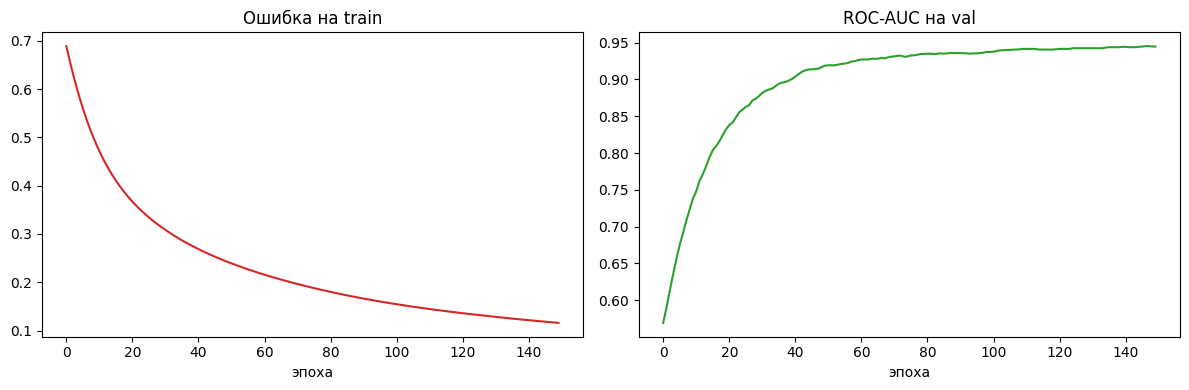

Эпоха 1:   loss 0.689, val ROC-AUC 0.569
Эпоха 150: loss 0.116, val ROC-AUC 0.945
Лучший val ROC-AUC: 0.945 на эпохе 147


In [7]:
net = MLPClassifier(hidden_layer_sizes=(32,), activation='relu', random_state=RANDOM_STATE)

history = {'loss': [], 'val_auc': []}
for epoch in range(1, 151):
    net.partial_fit(A_tr, y_tr, classes=[0, 1])
    history['loss'].append(net.loss_)
    history['val_auc'].append(roc_auc_score(y_va, net.predict_proba(A_va)[:, 1]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], color='tab:red')
ax1.set_title('Ошибка на train')
ax1.set_xlabel('эпоха')
ax2.plot(history['val_auc'], color='tab:green')
ax2.set_title('ROC-AUC на val')
ax2.set_xlabel('эпоха')
plt.tight_layout()
plt.show()

print(f"Эпоха 1:   loss {history['loss'][0]:.3f}, val ROC-AUC {history['val_auc'][0]:.3f}")
print(f"Эпоха 150: loss {history['loss'][-1]:.3f}, val ROC-AUC {history['val_auc'][-1]:.3f}")
print(f"Лучший val ROC-AUC: {max(history['val_auc']):.3f} на эпохе {int(np.argmax(history['val_auc'])) + 1}")

> **Итог шага:** ошибка на train падает с 0.69 до 0.12. ROC-AUC на val растёт с 0.57 до 0.945 и примерно после 80-й эпохи почти не меняется. Качество на val не падает — переобучения нет, 150 эпох хватает.

## Шаг 5. Качество

Смотрим на val и test. Главное для медицины — сколько больных модель пропустила (ложноотрицательные).

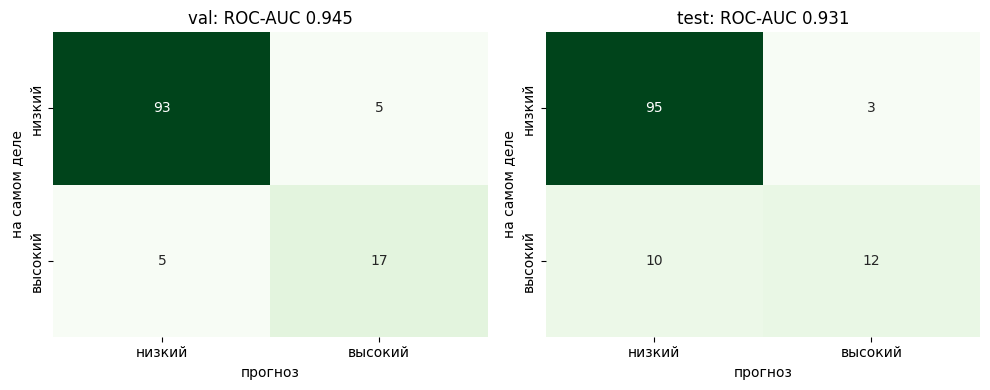

Отчёт по test:
              precision    recall  f1-score   support

      низкий      0.905     0.969     0.936        98
     высокий      0.800     0.545     0.649        22

    accuracy                          0.892       120
   macro avg      0.852     0.757     0.792       120
weighted avg      0.886     0.892     0.883       120



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, A, y_true) in zip(axes, [('val', A_va, y_va), ('test', A_te, y_te)]):
    y_hat = net.predict(A)
    sns.heatmap(confusion_matrix(y_true, y_hat), annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax,
                xticklabels=['низкий', 'высокий'], yticklabels=['низкий', 'высокий'])
    ax.set_title(f'{name}: ROC-AUC {roc_auc_score(y_true, net.predict_proba(A)[:, 1]):.3f}')
    ax.set_xlabel('прогноз')
    ax.set_ylabel('на самом деле')
plt.tight_layout()
plt.show()

print('Отчёт по test:')
print(classification_report(y_te, net.predict(A_te), target_names=['низкий', 'высокий'], digits=3))

В `classification_report`: *precision* — доля верных среди предсказанных как класс,
*recall* — доля найденных из реально принадлежащих классу. Recall строки «низкий» — это specificity,
recall строки «высокий» — чувствительность (сколько больных нашли).

> **Итог шага:** ROC-AUC 0.945 на val и 0.931 на test — модель хорошо ранжирует пациентов по риску. Здоровых определяет почти всех (95 из 98 на test). Слабое место — больные: на val найдено 17 из 22, на test только 12 из 22 (recall 0.55). Причины две: дисбаланс классов (сеть охотнее говорит «низкий риск») и маленький test, где один пациент меняет recall на 4.5%.

## Шаг 6. Прогноз и сохранение

In [9]:
result = pd.DataFrame({
    'patient_id': df_new['patient_id'],
    'prediction': net.predict(prepare(df_new)),
})

os.makedirs('../outputs', exist_ok=True)
result.to_csv('../outputs/task1_predictions.csv', index=False)

# Проверки формата сдачи
assert len(result) == len(df_new) and result['patient_id'].equals(df_new['patient_id'])
assert result.notna().all().all()
print(result['prediction'].value_counts().rename({0: 'низкий риск', 1: 'высокий риск'}))

prediction
низкий риск     172
высокий риск     28
Name: count, dtype: int64


> **Итог шага:** прогноз для всех 200 пациентов сохранён, id совпадают, пропусков нет. Высокий риск у 28 пациентов (14%) — меньше, чем 18% в обучающих данных. Это то же занижение, что видно по recall.

## Итог

- **Данные:** 800 пациентов, 15 признаков, высокий риск у 18%. Другие метки (`Статус_глюкозы`, `Доклинический_риск`) в признаки не брали.
- **Подготовка:** сначала разделение 70/15/15, потом только по train: удаление 8 выбросов (|z| > 3), заполнение пропусков средним, StandardScaler.
- **Модель:** MLP, 1 скрытый слой на 32 нейрона, ReLU, 150 эпох. Обучение стабильное, без переобучения.
- **Качество:** ROC-AUC 0.93–0.95, specificity 0.97, но больных находим только 55–77% (test / val).
- **Что можно улучшить:** снизить порог с 0.5 или взвесить классы — меньше пропущенных больных ценой большего числа ложных тревог.
- **Ограничения:** данные симулированные. Модель может помочь выбрать, кого дообследовать, но диагноз ставит врач.